# Análisis del tráfico del clúster y de la base de datos PostgreSQL

**Parcial 2 práctico - Comunicaciones (Ingeniería Mecatrónica)**

Este cuaderno viene **precargado** (bind-mount `./jupyter/notebooks -> /home/jovyan/work`) y se puede ejecutar completo con
**Run -> Run All Cells**. Hace lo siguiente:

1. **Capas 2 y 3**: muestra el DNS embebido de Docker (`127.0.0.11`), resuelve los nombres de servicio, lista las interfaces, las rutas y la tabla ARP del contenedor.
2. **Genera tráfico** real contra el portal Joomla *a través de Nginx* (incluye un inicio de sesión en el administrador para producir registros de actividad).
3. **Capa 7 / Capa 4 de PostgreSQL**: se conecta con `psycopg2` + `SQLAlchemy` al servicio `database:5432` con un usuario de solo lectura.
4. **Analiza los logs** de acceso de Nginx y de Apache/Joomla (expuestos en PostgreSQL con `file_fdw`): códigos HTTP, IPs recurrentes, rutas, latencias y reutilización de conexiones TCP keep-alive.
5. Consulta la **actividad del CMS** (registro de acciones y artículos más vistos).
6. **Verifica** los datos de la BD contra el archivo de log crudo montado en el contenedor.

In [1]:
import os, socket, time, re, ipaddress
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import requests
from sqlalchemy import create_engine, text

pd.set_option("display.max_colwidth", 80)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
TZ = os.environ.get("TZ", "America/Bogota")

DB = dict(host=os.environ.get("DB_HOST", "database"), port=int(os.environ.get("DB_PORT", 5432)),
          name=os.environ.get("DB_NAME", "joomla"), user=os.environ.get("DB_USER", "analista"),
          password=os.environ.get("DB_PASSWORD", ""))
PROXY_URL = os.environ.get("PROXY_URL", "http://nginx")
print(f"Contenedor: {socket.gethostname()}  |  Base de datos: {DB['user']}@{DB['host']}:{DB['port']}/{DB['name']}  |  Proxy: {PROXY_URL}")

Contenedor: jupyter  |  Base de datos: analista@database:5432/joomla  |  Proxy: http://nginx


## 1. Capa 3 y Capa 2 vistas desde el contenedor `jupyter`

Docker escribe en `/etc/resolv.conf` el servidor DNS embebido **127.0.0.11**. Ese resolvedor (implementado por el
demonio de Docker e interceptado con reglas NAT dentro del *namespace* de red del contenedor) responde con la IP que
tiene cada **nombre de servicio** en las redes que el contenedor comparte con él.

In [2]:
print(open("/etc/resolv.conf").read())

servicios = ["nginx", "joomla", "database", "grafana", "jupyter"]
filas = []
for s in servicios:
    try:
        ips = sorted({ai[4][0] for ai in socket.getaddrinfo(s, None, socket.AF_INET)})
    except socket.gaierror as e:
        ips = [f"no resuelve ({e.strerror})"]
    filas.append({"servicio": s, "IP(s) resueltas por 127.0.0.11": ", ".join(ips)})
pd.DataFrame(filas)

# Generated by Docker Engine.
# This file can be edited; Docker Engine will not make further changes once it
# has been modified.

nameserver 127.0.0.11
options ndots:0

# Based on host file: '/etc/resolv.conf' (internal resolver)
# ExtServers: [host(192.168.65.7)]
# Overrides: []
# Option ndots from: internal



,servicio,IP(s) resueltas por 127.0.0.11
0,nginx,10.201.10.5
1,joomla,10.201.10.4
2,database,10.201.20.2
3,grafana,10.201.10.2
4,jupyter,"10.201.10.3, 10.201.20.4"


In [3]:
def interfaces_locales():
    # Lee /proc/net/fib_trie para obtener las IPv4 locales de cada interfaz (no requiere 'ip')
    ips, prev = set(), None
    for linea in open("/proc/net/fib_trie"):
        linea = linea.strip()
        if "/32 host LOCAL" in linea and prev:
            ips.add(prev.split()[-1])
        prev = linea
    return sorted(ip for ip in ips if not ip.startswith("127."))

def hex_a_ip(h):
    return socket.inet_ntoa(bytes.fromhex(h)[::-1])

print("IPs de este contenedor (una por red bridge):", interfaces_locales())

rutas = []
for linea in list(open("/proc/net/route"))[1:]:
    c = linea.split()
    red, gw, mascara = hex_a_ip(c[1]), hex_a_ip(c[2]), hex_a_ip(c[7])
    prefijo = ipaddress.IPv4Network(f"0.0.0.0/{mascara}").prefixlen
    rutas.append({"interfaz": c[0], "destino": f"{red}/{prefijo}", "gateway": gw})
print("\nTabla de rutas (Capa 3):")
pd.DataFrame(rutas)

IPs de este contenedor (una por red bridge): ['10.201.10.3', '10.201.20.4']

Tabla de rutas (Capa 3):


,interfaz,destino,gateway
0,eth1,0.0.0.0/0,10.201.10.1
1,eth1,10.201.10.0/24,0.0.0.0
2,eth0,10.201.20.0/24,0.0.0.0


La ruta por defecto (`0.0.0.0/0`) sale solo por la interfaz de **frontend_net**: `backend_net` es una red `internal`
y no tiene gateway. A continuación se abre una conexión TCP a cada servicio para forzar la **resolución ARP** y se
lee la caché ARP del *namespace* (`/proc/net/arp`): cada IP vecina queda asociada a la dirección MAC de la interfaz
`veth` del otro contenedor, conectada al mismo puente `br-*`.

In [4]:
destinos = {"nginx": 80, "joomla": 80, "grafana": 3000, "database": 5432}
for host, puerto in destinos.items():
    try:
        with socket.create_connection((host, puerto), timeout=3) as s:
            print(f"TCP {s.getsockname()[0]}:{s.getsockname()[1]:<5} -> {host}:{puerto} ({s.getpeername()[0]})  conexión establecida")
    except OSError as e:
        print(f"TCP -> {host}:{puerto}  ERROR {e}")

arp = pd.read_csv("/proc/net/arp", sep=r"\s+", skiprows=1, names=["IP", "HW type", "Flags", "HW address", "Mask", "Device"])
mapa = {ai[4][0]: s for s in destinos for ai in socket.getaddrinfo(s, None, socket.AF_INET)}
arp["servicio"] = arp["IP"].map(mapa)
arp[["IP", "HW address", "Device", "servicio"]]

TCP 10.201.10.3:57502 -> nginx:80 (10.201.10.5)  conexión establecida
TCP 10.201.10.3:51650 -> joomla:80 (10.201.10.4)  conexión establecida
TCP 10.201.10.3:44242 -> grafana:3000 (10.201.10.2)  conexión establecida
TCP 10.201.20.4:51816 -> database:5432 (10.201.20.2)  conexión establecida


,IP,HW address,Device,servicio
0,10.201.10.4,26:bd:32:a6:b9:b3,eth1,joomla
1,10.201.10.1,e2:ac:e4:80:ae:6d,eth1,NaN
2,10.201.20.2,a6:29:d4:71:bf:74,eth0,database
3,10.201.10.2,56:98:35:52:ed:7f,eth1,grafana
4,10.201.10.5,ce:88:af:0f:f5:94,eth1,nginx


## 2. Generación de tráfico a través del proxy inverso

Las peticiones se hacen a `http://nginx` (el nombre del servicio en `frontend_net`). Nginx las registra con
`servicio = joomla` y las reenvía a Apache/Joomla por su pool de conexiones keep-alive. También se inicia sesión en
el administrador de Joomla para que el plugin *Action Log* escriba en la tabla `#__action_logs`.

In [5]:
rutas_demo = ["/", "/index.php/component/content/article/bienvenida-portal?catid=2",
              "/index.php/component/content/article/modelo-osi-en-contenedores?catid=2",
              "/index.php/component/content/article/proxy-inverso-nginx?catid=2",
              "/index.php/component/content/article/postgresql-fuente-de-datos?catid=2",
              "/index.php/component/content/article/segmentacion-de-redes?catid=2",
              "/index.php/component/content/article/monitoreo-con-grafana?catid=2",
              "/pagina-inexistente", "/wp-login.php", "/index.php/component/users/login"]

sesion = requests.Session()
sesion.headers["User-Agent"] = "Jupyter-Parcial/1.0 (generador de trafico)"
resultados = []
for vuelta in range(3):
    for ruta in rutas_demo:
        r = sesion.get(PROXY_URL + ruta, timeout=15, allow_redirects=False)
        resultados.append({"ruta": ruta.split("?")[0], "codigo": r.status_code, "ms": round(r.elapsed.total_seconds() * 1000, 1)})

# Inicio de sesión en el administrador (formulario con token CSRF)
usuario, clave = os.environ.get("JOOMLA_ADMIN_USERNAME"), os.environ.get("JOOMLA_ADMIN_PASSWORD")
if usuario and clave:
    adm = requests.Session()
    html = adm.get(PROXY_URL + "/administrator/index.php", timeout=15).text
    token = re.search(r'name="([a-f0-9]{32})" value="1"', html)
    datos = {"username": usuario, "passwd": clave, "option": "com_login", "task": "login", "return": "aW5kZXgucGhw"}
    if token:
        datos[token.group(1)] = "1"
    r = adm.post(PROXY_URL + "/administrator/index.php", data=datos, timeout=15)
    ok = "com_cpanel" in r.text or "Log out" in r.text or "logout" in r.text.lower()
    print("Inicio de sesión en /administrator:", "correcto" if ok else "no confirmado")
    adm.get(PROXY_URL + "/administrator/index.php?option=com_content&view=articles", timeout=15)

df_gen = pd.DataFrame(resultados)
print(f"Peticiones generadas: {len(df_gen)}")
df_gen.groupby(["ruta", "codigo"]).agg(peticiones=("ms", "size"), ms_promedio=("ms", "mean")).round(1)

Inicio de sesión en /administrator: correcto
Peticiones generadas: 30


,,peticiones,ms_promedio
ruta,codigo,,
/,200,3,70.4
/index.php/component/content/article/bienvenida-portal,200,3,87.3
/index.php/component/content/article/modelo-osi-en-contenedores,200,3,74.6
/index.php/component/content/article/monitoreo-con-grafana,200,3,79.2
/index.php/component/content/article/postgresql-fuente-de-datos,200,3,88.5
/index.php/component/content/article/proxy-inverso-nginx,200,3,83.8
/index.php/component/content/article/segmentacion-de-redes,200,3,89.3
/index.php/component/users/login,200,3,49.8
/pagina-inexistente,404,3,35.9


## 3. Conexión a PostgreSQL (`psycopg2` + `SQLAlchemy`)

`database` se resuelve por DNS a su IP en `backend_net`; la conexión es TCP al puerto **5432** y habla el protocolo
cliente/servidor de PostgreSQL (mensajes *StartupMessage*, autenticación SCRAM-SHA-256, *Query*, *RowDescription*,
*DataRow*...). El usuario `analista` es de **solo lectura** y solo ve el esquema `monitoreo`.

In [6]:
url = f"postgresql+psycopg2://{DB['user']}:{DB['password']}@{DB['host']}:{DB['port']}/{DB['name']}"
engine = create_engine(url, pool_size=2, pool_pre_ping=True,
                       connect_args={"application_name": "jupyter-analisis", "connect_timeout": 10})

with engine.connect() as con:
    info = con.execute(text('''
        SELECT current_user AS usuario, version() AS servidor,
               inet_server_addr()::text AS ip_servidor, inet_server_port() AS puerto_servidor,
               inet_client_addr()::text AS ip_cliente,  inet_client_port() AS puerto_cliente_efimero,
               current_setting('ssl') AS ssl
    ''')).mappings().one()
pd.Series(dict(info))

usuario                                                                                          analista
servidor                  PostgreSQL 16.15 on x86_64-pc-linux-musl, compiled by gcc (Alpine 15.2.0) 15...
ip_servidor                                                                                10.201.20.2/32
puerto_servidor                                                                                      5432
ip_cliente                                                                                 10.201.20.4/32
puerto_cliente_efimero                                                                              51820
ssl                                                                                                   off
dtype: object

In [7]:
def consulta(sql, **params):
    with engine.connect() as con:
        return pd.read_sql(text(sql), con, params=params)

consulta("SELECT usuario, aplicacion, ip_cliente, puerto_cliente, estado, inicio_conexion AT TIME ZONE :tz AS inicio_conexion "
         "FROM monitoreo.v_conexiones_pg ORDER BY 6", tz=TZ)

,usuario,aplicacion,ip_cliente,puerto_cliente,estado,inicio_conexion
0,analista,jupyter-analisis,10.201.20.4,51820,active,2026-09-25 11:27:18.157924


## 4. Análisis del log de acceso de Nginx (vista `monitoreo.v_nginx_accesos`)

In [8]:
time.sleep(1)  # margen para que Nginx escriba las últimas líneas
nginx = consulta("SELECT * FROM monitoreo.v_nginx_accesos")
nginx["ts"] = pd.to_datetime(nginx["ts"], utc=True).dt.tz_convert(TZ)
print(f"Registros en el log de Nginx: {len(nginx)}  |  desde {nginx.ts.min():%Y-%m-%d %H:%M:%S} hasta {nginx.ts.max():%H:%M:%S}")
nginx.pivot_table(index="servicio", columns="clase_estado", values="uri", aggfunc="count", fill_value=0)

Registros en el log de Nginx: 170  |  desde 2026-09-25 11:24:17 hasta 11:27:18


clase_estado,2xx,3xx,4xx
servicio,,,
joomla,51,1,14
jupyter,104,0,0


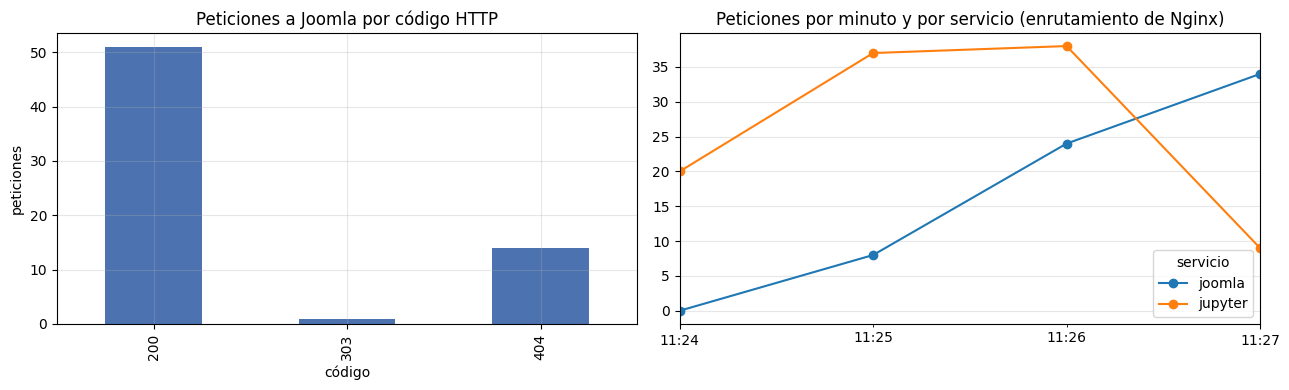

In [9]:
joomla = nginx[nginx.servicio == "joomla"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

joomla.estado.value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("Peticiones a Joomla por código HTTP"); ax[0].set_xlabel("código"); ax[0].set_ylabel("peticiones")

por_min = nginx.groupby([pd.Grouper(key="ts", freq="1min"), "servicio"]).size().unstack(fill_value=0)
por_min.plot(ax=ax[1], marker="o")
ax[1].set_title("Peticiones por minuto y por servicio (enrutamiento de Nginx)"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

In [10]:
top_ips = joomla.ip_origen.value_counts().head(10).rename("peticiones").to_frame()
top_rutas = (joomla.groupby("ruta")
             .agg(peticiones=("uri", "size"), codigos=("estado", lambda s: sorted(set(s))),
                  latencia_media_ms=("tiempo_total_s", lambda s: round(s.astype(float).mean() * 1000, 1)))
             .sort_values("peticiones", ascending=False).head(10))
display(top_ips)
display(top_rutas)

,peticiones
ip_origen,
10.201.10.3,34
10.201.10.1,32


,peticiones,codigos,latencia_media_ms
ruta,,,
/,7,[200],75.0
/index.php/component/content/article/modelo-osi-en-contenedores,7,[200],84.4
/index.php/component/content/article/bienvenida-portal,7,[200],101.6
/index.php/component/content/article/monitoreo-con-grafana,7,[200],81.3
/index.php/component/content/article/segmentacion-de-redes,7,[200],90.1
/.env,4,[404],36.0
/administrator/,4,[200],56.8
/administrator/index.php,4,"[200, 303]",144.0
/no-existe,4,[404],40.3


### Capa 4: reutilización de conexiones TCP (keep-alive) entre Nginx y los backends

`$upstream_connect_time = 0` significa que Nginx **no** tuvo que abrir una conexión TCP nueva (no hubo *three-way
handshake*): tomó una conexión ociosa del pool `keepalive` del bloque `upstream`. `upstream_addr` muestra la IP:puerto
del contenedor destino en `frontend_net`.

,conexion_tcp,nueva,reutilizada (0 ms)
servicio,upstream_addr,,
joomla,10.201.10.4:80,1,65
jupyter,10.201.10.3:8888,1,103


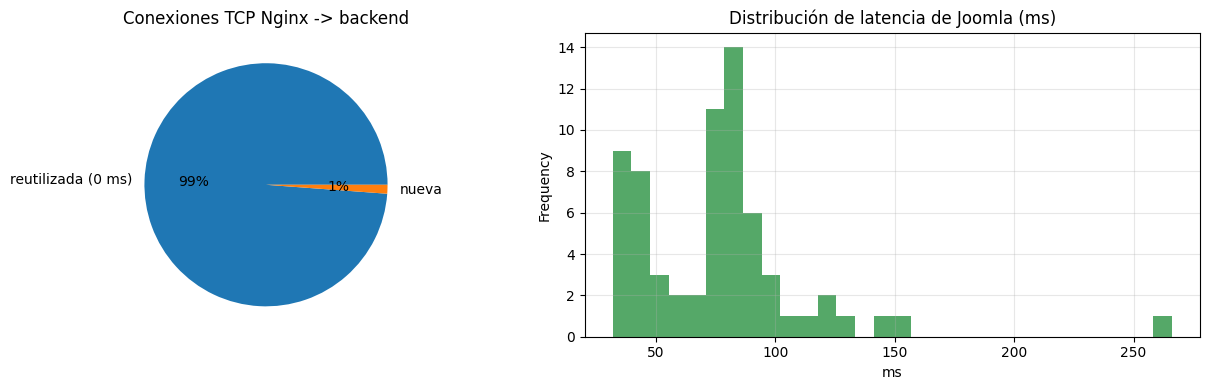

In [11]:
prox = nginx.dropna(subset=["upstream_connect_s"]).copy()
prox["conexion_tcp"] = prox.upstream_connect_s.astype(float).map(lambda x: "reutilizada (0 ms)" if x == 0 else "nueva")
resumen = prox.groupby(["servicio", "upstream_addr", "conexion_tcp"]).size().unstack(fill_value=0)
display(resumen)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
prox.conexion_tcp.value_counts().plot.pie(ax=ax[0], autopct="%1.0f%%", ylabel="")
ax[0].set_title("Conexiones TCP Nginx -> backend")
(joomla.tiempo_total_s.astype(float) * 1000).plot.hist(ax=ax[1], bins=30, color="#55A868")
ax[1].set_title("Distribución de latencia de Joomla (ms)"); ax[1].set_xlabel("ms")
plt.tight_layout(); plt.show()

## 5. Log de Apache dentro del contenedor Joomla (vista `monitoreo.v_joomla_apache`)

`ip_par_tcp` es la IP real del otro extremo de la conexión TCP (el contenedor **nginx**), mientras que `ip_cliente`
es la IP original reconstruida por `mod_remoteip` a partir de la cabecera **X-Forwarded-For** que inyecta Nginx.
`peticiones_keepalive` (`%k` de Apache) cuenta cuántas peticiones previas viajaron por la misma conexión TCP.

In [12]:
apache = consulta("SELECT * FROM monitoreo.v_joomla_apache ORDER BY ts")
apache["ts"] = pd.to_datetime(apache["ts"], utc=True).dt.tz_convert(TZ)
print("IP de nginx según el DNS de Docker:", socket.gethostbyname("nginx"))
display(apache.groupby(["ip_par_tcp", "ip_cliente", "x_forwarded_proto"]).size().rename("peticiones").to_frame())
print(f"Peticiones que llegaron por una conexión TCP reutilizada: {(apache.peticiones_keepalive > 0).mean():.0%}")
apache.tail(8)[["ts", "ip_cliente", "ip_par_tcp", "metodo", "ruta", "estado", "duracion_ms", "peticiones_keepalive"]]

IP de nginx según el DNS de Docker: 10.201.10.5


peticiones
ip_par_tcp  ip_cliente  x_forwarded_proto            
10.201.10.5 10.201.10.1 http                       32
            10.201.10.3 http                       34

Peticiones que llegaron por una conexión TCP reutilizada: 68%


,ts,ip_cliente,ip_par_tcp,metodo,ruta,estado,duracion_ms,peticiones_keepalive
77,2026-09-25 11:27:17-05:00,10.201.10.3,10.201.10.5,GET,/pagina-inexistente,404,32.28,27
78,2026-09-25 11:27:17-05:00,10.201.10.3,10.201.10.5,GET,/wp-login.php,404,33.22,28
79,2026-09-25 11:27:17-05:00,10.201.10.3,10.201.10.5,GET,/index.php/component/users/login,200,47.93,29
80,2026-09-25 11:27:17-05:00,10.201.10.3,10.201.10.5,GET,/administrator/index.php,200,44.13,30
81,2026-09-25 11:27:17-05:00,10.201.10.3,10.201.10.5,POST,/administrator/index.php,303,265.92,31
82,2026-09-25 11:27:17-05:00,10.201.10.3,10.201.10.5,GET,/administrator/index.php,200,146.50,32
83,2026-09-25 11:27:17-05:00,10.201.10.3,10.201.10.5,GET,/administrator/index.php,200,118.62,33
84,2026-09-25 11:27:18-05:00,127.0.0.1,127.0.0.1,GET,/index.php,200,73.50,0


## 6. Actividad del CMS Joomla en PostgreSQL

,fecha,usuario,extension,accion,item_id,ip
0,2026-09-25 11:27:17-05:00,admin,com_users,user logged in,0,10.201.10.3


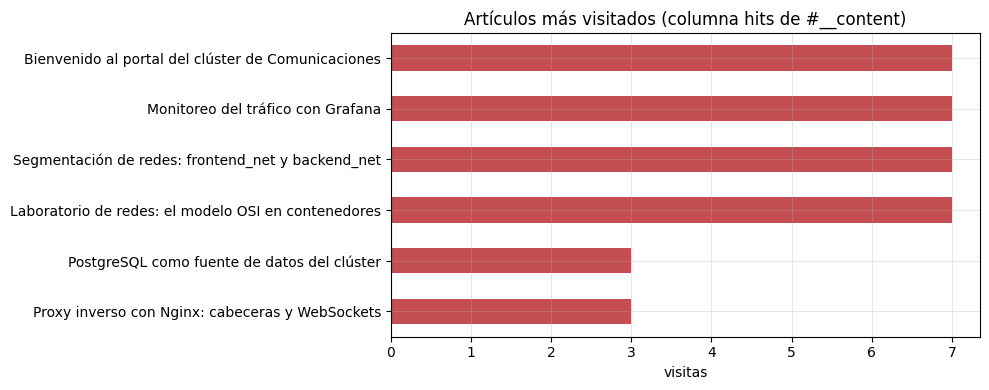

In [13]:
actividad = consulta("SELECT * FROM monitoreo.v_actividad_joomla ORDER BY fecha DESC LIMIT 15")
actividad["fecha"] = pd.to_datetime(actividad["fecha"], utc=True).dt.tz_convert(TZ)
display(actividad)

articulos = consulta("SELECT titulo, hits FROM monitoreo.v_articulos_joomla WHERE publicado ORDER BY hits")
ax = articulos.plot.barh(x="titulo", y="hits", legend=False, color="#C44E52", figsize=(10, 4))
ax.set_title("Artículos más visitados (columna hits de #__content)"); ax.set_ylabel(""); ax.set_xlabel("visitas")
plt.tight_layout(); plt.show()

## 7. Verificación cruzada con el archivo de log crudo

El mismo volumen `nginx_logs` está montado en este contenedor en solo lectura (`/home/jovyan/logs/nginx`).
Se lee el archivo TSV directamente con pandas y se compara con lo que devuelve PostgreSQL.

In [14]:
columnas = ["msec", "time_iso", "remote_addr", "xff", "metodo", "uri", "protocolo", "estado", "bytes", "request_time",
            "upstream_addr", "upstream_status", "upstream_response_time", "upstream_connect_time", "conexion_id",
            "conexion_peticiones", "servicio", "host", "referer", "user_agent"]
crudo = pd.read_csv("/home/jovyan/logs/nginx/access.log", sep="\t", names=columnas, quoting=3,
                    encoding="latin-1", dtype=str)
en_bd = consulta("SELECT count(*) AS n FROM monitoreo.v_nginx_accesos").n[0]
print(f"Líneas en el archivo: {len(crudo)}  |  filas vistas por PostgreSQL: {en_bd}")
print("Coinciden" if abs(len(crudo) - en_bd) <= 5 else "Diferencia (el log sigue creciendo mientras se consulta)")
crudo.tail(3)

Líneas en el archivo: 172  |  filas vistas por PostgreSQL: 172
Coinciden


,msec,time_iso,remote_addr,xff,metodo,uri,protocolo,estado,bytes,request_time,upstream_addr,upstream_status,upstream_response_time,upstream_connect_time,conexion_id,conexion_peticiones,servicio,host,referer,user_agent
169,1790353638.889,2026-09-25T11:27:18-05:00,10.201.10.1,-,PUT,/jupyter/lab/api/workspaces/default?1790353638886,HTTP/1.1,204,0,0.002,10.201.10.3:8888,204,0.002,0.000,2,104,jupyter,localhost,http://localhost/jupyter/lab/tree/work/analisis_datos.ipynb,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Ge..."
170,1790353639.468,2026-09-25T11:27:19-05:00,10.201.10.1,-,GET,/jupyter/api/sessions?1790353639465,HTTP/1.1,200,2,0.001,10.201.10.3:8888,200,0.001,0.000,2,105,jupyter,localhost,http://localhost/jupyter/lab/tree/work/analisis_datos.ipynb,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Ge..."
171,1790353639.847,2026-09-25T11:27:19-05:00,10.201.10.1,-,GET,/jupyter/api/kernelspecs?1790353639844,HTTP/1.1,200,565,0.002,10.201.10.3:8888,200,0.002,0.000,2,106,jupyter,localhost,http://localhost/jupyter/lab/tree/work/analisis_datos.ipynb,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Ge..."


## Conclusiones

* El DNS embebido de Docker (**127.0.0.11**) resuelve cada nombre de servicio a su IP en la red compartida; `database`
  solo es alcanzable por `backend_net` y no tiene ruta al exterior.
* En Capa 2 cada contenedor ve a sus vecinos del mismo puente por su dirección MAC (tabla ARP), a través de pares `veth`.
* Nginx reutiliza conexiones TCP hacia los backends (keep-alive), lo que evita un *three-way handshake* por petición.
* Apache recibe la IP del cliente original gracias a **X-Forwarded-For** y `mod_remoteip`, mientras que la IP del par TCP es Nginx.
* PostgreSQL centraliza los datos: los logs (vía `file_fdw`) y la actividad del CMS son consultables desde Grafana y Jupyter
  con usuarios de solo lectura.